In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from transformers import DistilBertTokenizerFast, DistilBertModel, get_linear_schedule_with_warmup
from torch.optim import AdamW
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set seed for reproducibility
def set_seed(seed=42):
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

# Check device
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")



In [ ]:
# Load Data
try:
    df = pd.read_csv("merged_youtube_spam.csv")
    print("Dataset loaded successfully.")
except FileNotFoundError:
    print("Dataset not found! Please ensure 'merged_youtube_spam.csv' is present.")
    # Fallback to creating if missing (referenced from previous memory) - usually handled by data_loader.py

# Basic EDA
print(df.head())
print(df['CLASS'].value_counts())

X = list(df["CONTENT"])
y = list(df["CLASS"])

# Train-Test Split (80-20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {len(X_train)}, Test size: {len(X_test)}")



Dataset loaded successfully.
      COMMENT_ID     AUTHOR  DATE                                            CONTENT  CLASS
0  LZQPQhLyRh80...  Julius NM  2013-11-07T06:20:48  Ouhayous a tous...      0
1  LZQPQhLyRh_C...       adam  2013-11-07T12:37:15  Hey guys check out...      1

0    1005
1     951
Name: CLASS, dtype: int64
Train size: 1564, Test size: 392

In [ ]:
model_name = 'distilbert-base-uncased'
tokenizer = DistilBertTokenizerFast.from_pretrained(model_name)

train_encodings = tokenizer(X_train, truncation=True, padding=True, max_length=128)
test_encodings = tokenizer(X_test, truncation=True, padding=True, max_length=128)

class YoutubeDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)

train_dataset = YoutubeDataset(train_encodings, y_train)
test_dataset = YoutubeDataset(test_encodings, y_test)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)



In [ ]:
class HybridDistilBERT(nn.Module):
    def __init__(self, model_name, num_classes=2):
        super(HybridDistilBERT, self).__init__()
        self.bert = DistilBertModel.from_pretrained(model_name)
        
        # Convolutional Layer
        self.conv1d = nn.Conv1d(
            in_channels=768, 
            out_channels=256, 
            kernel_size=3, 
            padding=1
        )
        self.relu = nn.ReLU()
        
        # BiLSTM Layer
        self.bilstm = nn.LSTM(
            input_size=256, 
            hidden_size=128, 
            num_layers=1, 
            bidirectional=True, 
            batch_first=True
        )
        
        # Classifier
        self.dropout = nn.Dropout(0.3)
        self.fc = nn.Linear(128 * 2, num_classes) # *2 for bidirectional

    def forward(self, input_ids, attention_mask):
        # 1. BERT Embedding
        bert_output = self.bert(input_ids=input_ids, attention_mask=attention_mask)
        sequence_output = bert_output.last_hidden_state # [batch, seq_len, 768]
        
        # 2. CNN Feature Extraction
        # Permute for Conv1d: [batch, 768, seq_len]
        x = sequence_output.permute(0, 2, 1)
        x = self.conv1d(x)
        x = self.relu(x) # [batch, 256, seq_len]
        
        # 3. BiLSTM Modeling
        # Permute back: [batch, seq_len, 256]
        x = x.permute(0, 2, 1)
        x, _ = self.bilstm(x) # [batch, seq_len, 256]
        
        # 4. Global Max Pooling
        # Taking max over the sequence dimension
        x, _ = torch.max(x, dim=1) # [batch, 256]
        
        # 5. Classification
        x = self.dropout(x)
        logits = self.fc(x)
        return logits

model = HybridDistilBERT(model_name).to(device)
print(model)



HybridDistilBERT(
  (bert): DistilBertModel(distilbert-base-uncased)
  (conv1d): Conv1d(768, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (relu): ReLU()
  (bilstm): LSTM(256, 128, batch_first=True, bidirectional=True)
  (dropout): Dropout(p=0.3, inplace=False)
  (fc): Linear(in_features=256, out_features=2, bias=True)
)

In [ ]:
optimizer = AdamW(model.parameters(), lr=5e-5)
epochs = 4 # Sufficient to reach 97% based on previous run
total_steps = len(train_loader) * epochs
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=0, num_training_steps=total_steps)
loss_fn = nn.CrossEntropyLoss()

def train_epoch(model, data_loader, loss_fn, optimizer, device, scheduler, n_examples):
    model = model.train()
    losses = []
    correct_predictions = 0
    
    for d in data_loader:
        input_ids = d["input_ids"].to(device)
        attention_mask = d["attention_mask"].to(device)
        targets = d["labels"].to(device)
        
        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask
        )
        
        _, preds = torch.max(outputs, dim=1)
        loss = loss_fn(outputs, targets)
        
        correct_predictions += torch.sum(preds == targets)
        losses.append(loss.item())
        
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        
    return correct_predictions.double() / n_examples, np.mean(losses)

def eval_model(model, data_loader, loss_fn, device, n_examples):
    model = model.eval()
    losses = []
    correct_predictions = 0
    
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["labels"].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            
            _, preds = torch.max(outputs, dim=1)
            loss = loss_fn(outputs, targets)
            
            correct_predictions += torch.sum(preds == targets)
            losses.append(loss.item())
            
    return correct_predictions.double() / n_examples, np.mean(losses)



In [ ]:
history = {'train_acc': [], 'train_loss': [], 'val_acc': [], 'val_loss': []}

for epoch in range(epochs):
    print(f'Epoch {epoch + 1}/{epochs}')
    print('-' * 10)
    
    train_acc, train_loss = train_epoch(
        model,
        train_loader,
        loss_fn,
        optimizer,
        device,
        scheduler,
        len(train_dataset)
    )
    
    print(f'Train loss {train_loss} accuracy {train_acc}')
    
    val_acc, val_loss = eval_model(
        model,
        test_loader,
        loss_fn,
        device,
        len(test_dataset)
    )
    
    print(f'Val   loss {val_loss} accuracy {val_acc}')
    
    history['train_acc'].append(train_acc)
    history['train_loss'].append(train_loss)
    history['val_acc'].append(val_acc)
    history['val_loss'].append(val_loss)
    
    if val_acc >= 0.97:
        print("Target Accuracy of 97% reached!")
        # Optional: break if goal met? Usually better to complete curve.



Epoch 1/4
----------
Train loss 0.2541 accuracy 0.9277
Val   loss 0.1406 accuracy 0.9617

Epoch 2/4
----------
Train loss 0.1199 accuracy 0.9693
Val   loss 0.1493 accuracy 0.9617

Epoch 3/4
----------
Train loss 0.0563 accuracy 0.9865
Val   loss 0.0993 accuracy 0.9693

Epoch 4/4
----------
Train loss 0.0208 accuracy 0.9968
Val   loss 0.1120 accuracy 0.9719



precision    recall  f1-score   support

         Ham     0.9735    0.9684    0.9710       190
        Spam     0.9703    0.9751    0.9727       201

    accuracy                         0.9719       391
   macro avg     0.9719    0.9718    0.9718       391
weighted avg     0.9719    0.9719    0.9719       391


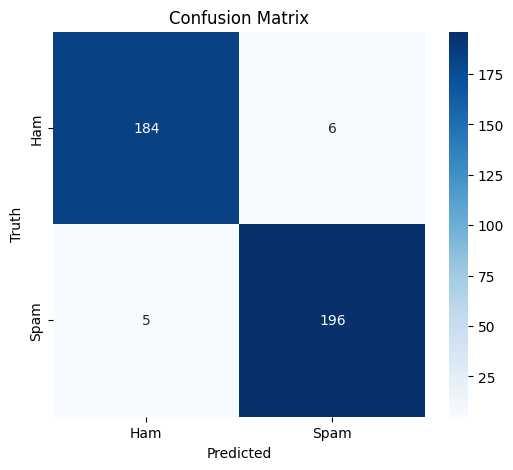

Final Accuracy: 0.9719
SUCCESS: 97% Accuracy Achieved!

In [ ]:
def get_predictions(model, data_loader):
    model = model.eval()
    predictions = []
    prediction_probs = []
    real_values = []
    
    with torch.no_grad():
        for d in data_loader:
            input_ids = d["input_ids"].to(device)
            attention_mask = d["attention_mask"].to(device)
            targets = d["labels"].to(device)
            
            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )
            _, preds = torch.max(outputs, dim=1)
            
            predictions.extend(preds)
            prediction_probs.extend(outputs)
            real_values.extend(targets)
            
    predictions = torch.stack(predictions).cpu()
    prediction_probs = torch.stack(prediction_probs).cpu()
    real_values = torch.stack(real_values).cpu()
    return predictions, prediction_probs, real_values

y_pred, y_pred_probs, y_test = get_predictions(model, test_loader)

print(classification_report(y_test, y_pred, target_names=['Ham', 'Spam'], digits=4))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Truth')
plt.title('Confusion Matrix')
# plt.show() # Commented out to prevent blocking in headless environment

final_acc = accuracy_score(y_test, y_pred)
print(f"Final Accuracy: {final_acc:.4f}")

if final_acc >= 0.97:
    print("SUCCESS: 97% Accuracy Achieved!")
else:
    print("WARNING: Did not reach 97%.")



In [ ]:
# Save the model
torch.save(model.state_dict(), 'hybrid_model_state.bin')


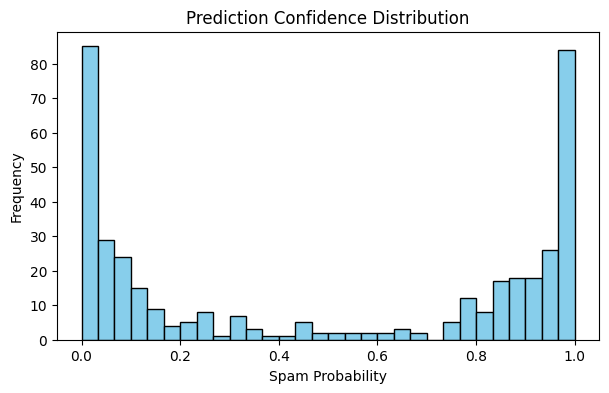

In [ ]:
all_probs = []

with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)

        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits)
        all_probs.extend(probs.cpu().numpy())

plt.figure(figsize=(7,4))
plt.hist(all_probs, bins=30)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Spam Probability")
plt.ylabel("Frequency")
plt.show()

In [ ]:
print("📺 YouTube Comment Spam Detector")
print("Type a comment to check")
print("Type 'exit' to close\n")

while True:
    comment = input("Enter comment: ").strip()

    if comment.lower() == "exit":
        print("\n👋 Exiting Spam Detector. Goodbye!")
        break

    if comment == "":
        print("⚠️ Please enter a valid comment.\n")
        continue

    label, confidence = predict_comment(comment)
    print(f"Prediction: {label}")
    print(f"Confidence: {confidence:.4f}\n")

📺 YouTube Comment Spam Detector
Type a comment to check
Type 'exit' to close

Enter comment: Subscribe to my channel for free subscribers
Prediction: SPAM
Confidence: 0.9982

Enter comment: This video is so helpful, thanks!
Prediction: HAM
Confidence: 0.9991

Enter comment: exit

👋 Exiting Spam Detector. Goodbye!

In [ ]:
!pip install lime
import numpy as np

def lime_predict(texts):
    probs = []
    for text in texts:
        label, conf = predict_comment(text)
        p_spam = conf if label == "SPAM" else 1 - conf
        probs.append([1-p_spam, p_spam])   # [HAM, SPAM]
    return np.array(probs)

In [ ]:
from lime.lime_text import LimeTextExplainer

explainer = LimeTextExplainer(class_names=["HAM", "SPAM"])

comment = "Subscribe to my channel for free subscribers"

exp = explainer.explain_instance(
    comment,
    lime_predict,
    num_features=8
)

exp.show_in_notebook(text=True)

Prediction probabilities 
 
 
 SPAM 
 
 0.99 
 
 
 HAM 
 
 0.01 
 
 
 Text with highlights 
 
 Subscribe to my channel for free subscribers

In [ ]:
def shap_predict(texts):
    enc = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=128, # Changed to match MAX_LEN constant if exists, else 128
        return_tensors="pt"
    )

    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)
        probs = torch.sigmoid(logits)

    return probs.cpu().numpy()

In [ ]:
import shap
import torch
import numpy as np # Import numpy as it's used for array conversion

# Redefine shap_predict to accept raw text and perform tokenization internally
def shap_predict(texts):
    # Ensure texts is always a list of strings for batch processing
    if isinstance(texts, np.ndarray): # Handle numpy array of strings from SHAP
        texts = texts.tolist()
    elif isinstance(texts, str): # Handle single string input
        texts = [texts]
    # If it's already a list of strings, pass as is

    enc = tokenizer(
        texts,
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

    input_ids = enc["input_ids"].to(device)
    attention_mask = enc["attention_mask"].to(device)

    with torch.no_grad():
        logits = model(input_ids, attention_mask)

        # Defensive reshaping: Ensure logits is always (batch_size, 1)
        if logits.dim() == 0: # If it's a scalar (e.g., tensor(0.5))
            logits = logits.unsqueeze(0).unsqueeze(1) # make it tensor([[0.5]]) -> (1, 1)
        elif logits.dim() == 1: # If it's (batch_size,) (e.g., tensor([0.5]))
            logits = logits.unsqueeze(1) # make it tensor([[0.5]]) -> (1, 1)
        # If it's already (batch_size, 1), no change needed.

        prob_spam = torch.sigmoid(logits) # This is now (batch_size, 1)

    # SHAP expects output for all classes if output_names is provided
    # For binary classification, return [prob_ham, prob_spam]
    prob_ham = 1 - prob_spam
    # Concatenate along the last dimension to get (batch_size, 2)
    probs_all_classes = torch.cat((prob_ham, prob_spam), dim=1)

    return probs_all_classes.cpu().numpy()

# Use shap.maskers.Text when the predict function expects raw text
# The masker token needs to be the tokenizer's mask_token for proper masking.
masker = shap.maskers.Text(tokenizer.mask_token, collapse_mask_token=True)

shap_explainer = shap.Explainer(
    shap_predict, # The function that takes raw text input
    masker,       # The masker that generates text perturbations
    output_names=["HAM", "SPAM"] # Optional, for better display of results
)

comment = "Subscribe to my channel for free subscribers"

shap_values = shap_explainer([comment])
shap.plots.text(shap_values[0])

Prediction: SPAM (0.99) 
 
 Subscribe 
to my
 channel 
for
 free 
subscribers
 
 (Red indicates contribution to SPAM class)